<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/5_Aprendizaje_supervisado/4_Taller_KNN_y_Arboles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller KNN y Árboles de Decisión**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- David Felipe Ruiz Parra
-
-

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Taller_KNN_arbol_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/3br4TfA3Ly.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

7 de mayo de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.



### **Contexto del Caso**

Un banco portugués lo ha contratado como consultor de ciencia de datos. El banco tiene un problema de eficiencia: sus campañas de telemercadeo para ofrecer depósitos a plazo tienen una tasa de éxito muy baja. Se invierte mucho tiempo y recursos (costos de call center) llamando a clientes que no están interesados.

**Su misión:** Construir y optimizar modelos de Machine Learning que predigan qué clientes tienen mayor probabilidad de decir **"sí"** a la oferta (`y = 'yes'`).

El banco no solo quiere un modelo preciso, también quiere entender **POR QUÉ** un cliente es un buen prospecto. Su segundo objetivo es identificar cuáles son las **variables más relevantes** que usan los modelos para tomar sus decisiones. Esto permitirá al banco no solo enfocar sus llamadas, sino también crear mejores guiones de marketing y entender mejor a su clientela.

**El Dataset:** `bank-additional.csv` se encuentra en el repositorio del curso. Contiene información de más de 4.000 contactos de telemercadeo, incluyendo datos demográficos del cliente e información de la campaña (último contacto, resultado anterior).

**Para mayor información y descripción de las variables:** https://archive.ics.uci.edu/dataset/222/bank+marketing

## 1. Preparación del Entorno y Datos

### 1.1. Carga de Librerías

Importe todas las librerías necesarias. Para problemas de clasificación se usa KNeighborsClassifier y DecisionTreeClassifier.

In [1]:
### TU CÓDIGO AQUÍ ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Mejorar visualización de dataframes y gráficos
pd.options.display.max_columns = None
pd.options.display.float_format = '{:.2f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Mejorar visualización de dataframes y gráficos

In [2]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# Configuraciones para una mejor visualización
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2. Carga y Exploración Inicial

In [9]:
# 1.2.1: Cargue el dataset
# ### TU CÓDIGO AQUÍ ###
# Usa sep=';'
df = pd.read_csv('bank-additional.csv', sep=';')

df.drop(columns=['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'], inplace=True)

# 1.2.2: Muestre las primeras 5 filas
# ### TU CÓDIGO AQUÍ ###
print("Primeras 5 filas del dataset:")
print(df.head())


Primeras 5 filas del dataset:
   age          job  marital          education default  housing     loan  \
0   30  blue-collar  married           basic.9y      no      yes       no   
1   39     services   single        high.school      no       no       no   
2   25     services  married        high.school      no      yes       no   
3   38     services  married           basic.9y      no  unknown  unknown   
4   47       admin.  married  university.degree      no      yes       no   

     contact month day_of_week  campaign  pdays  previous     poutcome   y  
0   cellular   may         fri         2    999         0  nonexistent  no  
1  telephone   may         fri         4    999         0  nonexistent  no  
2  telephone   jun         wed         1    999         0  nonexistent  no  
3  telephone   jun         fri         3    999         0  nonexistent  no  
4   cellular   nov         mon         1    999         0  nonexistent  no  


In [10]:
# 1.2.3: Use .info() para revisar los tipos de datos y los nulos
# ### TU CÓDIGO AQUÍ ###
print("\nInformación del dataset:")
print(df.info())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          4119 non-null   int64 
 1   job          4119 non-null   object
 2   marital      4119 non-null   object
 3   education    4119 non-null   object
 4   default      4119 non-null   object
 5   housing      4119 non-null   object
 6   loan         4119 non-null   object
 7   contact      4119 non-null   object
 8   month        4119 non-null   object
 9   day_of_week  4119 non-null   object
 10  campaign     4119 non-null   int64 
 11  pdays        4119 non-null   int64 
 12  previous     4119 non-null   int64 
 13  poutcome     4119 non-null   object
 14  y            4119 non-null   object
dtypes: int64(4), object(11)
memory usage: 482.8+ KB
None


**Escriba un análisis de lo obseervado en `info()`:**
Dado el tipo de datos de la base, qué preprocesamientos hay que realizar antes de correr los modelos?

Antes de aplicar cualquier modelo de Machine Learning, debemos realizar las siguientes transformaciones:

1. Escalar las variables numéricas

Las variables numéricas están en escalas muy diferentes. Por ejemplo, la edad puede estar entre 18 y 100 años, mientras que el número de contactos puede llegar a 50 o más. El modelo KNN es especialmente sensible a estas diferencias de escala, ya que calcula distancias entre puntos. Para solucionarlo, aplicaremos StandardScaler, que transforma los datos para que tengan media cero y desviación estándar uno.

2. Codificar las variables categóricas

Los modelos de Machine Learning solo entienden números, no texto. Por lo tanto, debemos convertir las 11 variables categóricas en números. Utilizaremos OneHotEncoder, que crea una nueva columna por cada categoría posible. Por ejemplo, la variable marital que puede tener valores "single", "married" o "divorced" se convertirá en tres columnas separadas, cada una con valores 0 o 1.

3. Manejar los valores 'unknown'

Aunque no hay valores nulos, existen valores escritos como 'unknown' en variables como housing o loan. Esto representa información que no se registró. No debemos eliminarlos ni tratarlos como errores, sino mantenerlos como una categoría más dentro de la codificación.

4. Consideraciones especiales para la variable postcode

El código postal es una variable categórica con muchos valores diferentes (más de 400 posibles). Esto puede generar muchas columnas nuevas después de la codificación, lo que podría afectar el rendimiento. Sería recomendable evaluar si esta variable realmente aporta información útil al modelo.

5. Unificar todo en un Pipeline

Para mantener un código ordenado y evitar errores, agruparemos todos estos pasos en un ColumnTransformer. Esto nos permitirá aplicar las transformaciones correctas a cada tipo de variable de manera automática.

Conclusión
En resumen, necesitamos escalar las 4 variables numéricas y codificar las 11 variables categóricas. Usaremos un Pipeline que aplique StandardScaler a las numéricas y OneHotEncoder a las categóricas. Esto preparará los datos para que tanto KNN como el Árbol de Decisión puedan procesarlos correctamente.

In [11]:
# 1.2.4: Revise el balance de la variable objetivo 'y'
# Use .value_counts() con normalize=True

# ### TU CÓDIGO AQUÍ ###
print("\nDistribución de la variable objetivo 'y':")
print(df['y'].value_counts())
print("\nDistribución porcentual:")
print(df['y'].value_counts(normalize=True) * 100)


Distribución de la variable objetivo 'y':
y
no     3668
yes     451
Name: count, dtype: int64

Distribución porcentual:
y
no    89.05
yes   10.95
Name: proportion, dtype: float64


**Escriba un análisis de la variable objetivo:**
¿Es un dataset desbalanceado? ¿Esto tiene lógica? ¿Qué implicaciones tiene esto respecto a las métricas que debemos usar?

Después de revisar la variable y (que indica si el cliente aceptó o no la oferta del banco), encontramos lo siguiente:

Clientes que dijeron "no": 3,668 personas, lo que representa el 89.05% del total

Clientes que dijeron "sí": 451 personas, lo que representa el 10.95% del total

Es decir, por cada cliente que acepta la oferta, hay aproximadamente 9 que la rechazan.
Sí, el dataset está desbalanceado. Decimos que un conjunto de datos está desbalanceado cuando una clase (en este caso el "no") tiene muchos más ejemplos que la otra clase (el "sí").

Sí, tiene toda la lógica del mundo. En la vida real, cuando un banco hace llamadas para ofrecer un producto, la mayoría de las personas rechazan la oferta. La gente está ocupada, no le gusta que la llamen, o simplemente no necesita el producto en ese momento. Por lo tanto, que solo 1 de cada 10 clientes diga que "sí" es un escenario completamente realista.

Esta es la parte más importante. El desbalance afecta cómo debemos medir si nuestro modelo funciona bien o no.

Imaginemos que creamos un modelo muy vago que simplemente predice "no" para todos los clientes, sin importar nada. Este modelo acertaría en el 89.05% de los casos. ¡Parecería un modelo excelente! Pero en realidad es un modelo inútil porque nunca identificaría a ningún cliente interesado.

Conclusión: No podemos usar el porcentaje de aciertos como nuestra métrica principal. Nos daría una falsa sensación de éxito.

## 2. Preprocesamiento (Usando Pipelines)

Vamos a definir nuestro `X` e `y`, y luego crear un `ColumnTransformer` que se encargue de aplicar `StandardScaler` a los números y `OneHotEncoder` a las categorías.

In [12]:
# 2.1: Separe X (predictoras) e y (objetivo)

# ### TU CÓDIGO AQUÍ ###

X = df.drop('y', axis=1)
y = df['y']


In [13]:
# 2.2: Divida en train y test (80/20)
# ¡Use stratify=y para mantener la proporción de 'yes' y 'no' en ambos sets!

# ### TU CÓDIGO AQUÍ ###
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño Train: {X_train.shape}")
print(f"Tamaño Test: {X_test.shape}")

Tamaño Train: (3295, 14)
Tamaño Test: (824, 14)


In [14]:
# 2.3: Identifique automáticamente las columnas numéricas y categóricas

# ### TU CÓDIGO AQUÍ ###
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Columnas Numéricas:")
print(numerical_features)
print("\nColumnas Categóricas:")
print(categorical_features)

Columnas Numéricas:
['age', 'campaign', 'pdays', 'previous']

Columnas Categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [15]:
# 2.4: Cree el ColumnTransformer (preprocessor) para estandarizar las variables numéricas y
# realizar One-Hot-Encoding de las variables categóricas

# Crear los transformadores individuales
# ### TU CÓDIGO AQUÍ ###
numeric_transformer = StandardScaler()

# ### TU CÓDIGO AQUÍ ###
# handle_unknown='ignore' es clave
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')


# Unirlos en el preprocesador usando ColumnTransformer
# ### TU CÓDIGO AQUÍ ###
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 3. Modelo 1: KNN

Ahora uniremos el preprocesador y el clasificador KNN en un solo `Pipeline` y usaremos `GridSearchCV` para encontrar el mejor `k`.

In [16]:
# 3.1: Cree el Pipeline completo de KNN
# (una el 'preprocessor' con el modelo 'KNeighborsClassifier')

# ### TU CÓDIGO AQUÍ ###
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

# 3.2: Definir la grilla de hiperparámetros para KNN
# Queremos probar k = 3, 5, 7, 11 (valores impares para evitar empates)
# Pista: El nombre DEBE ser 'model__n_neighbors' (por el nombre en el pipeline)

# ### TU CÓDIGO AQUÍ ###
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 11]
}

# 3.3: Configurar y ejecutar GridSearchCV
# Use 3 folds (cv=3) para que corra más rápido.
# Use scoring='recall_macro'.

# ### TU CÓDIGO AQUÍ ###
grid_knn = GridSearchCV(
    knn_pipeline,
    param_grid_knn,
    cv=3,
    scoring='recall_macro',
    n_jobs=-1
)
grid_knn.fit(X_train, y_train)




# 3.4: Mostrar los mejores resultados
print(f"Mejor valor de 'k' para KNN: {grid_knn.best_params_}")
print(f"Mejor Recall-Macro: {grid_knn.best_score_:.4f}")

Mejor valor de 'k' para KNN: {'model__n_neighbors': 3}
Mejor Recall-Macro: 0.5882


## 4. Modelo 2: Árbol de Decisión

Repetiremos el proceso con un Árbol de Decisión. Esta vez, los hiperparámetros que ajustaremos serán `max_depth` (para evitar sobreajuste) y `min_samples_leaf`.

In [17]:
# 4.1: Crear el Pipeline completo para el Árbol de Decisión
# (une el 'preprocessor' con el modelo 'DecisionTreeClassifier')

# ### TU CÓDIGO AQUÍ ###

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# 4.2: Definir la grilla de hiperparámetros para el Árbol
# Probaremos 'max_depth' = [3, 5, 7]
# Y 'min_samples_leaf' = [20, 50, 100] (para controlar la complejidad)

# ### TU CÓDIGO AQUÍ ###
param_grid_tree = {
    'model__max_depth': [3, 5, 7],
    'model__min_samples_leaf': [20, 50, 100]
}


# 4.3: Configurar y ejecutar GridSearchCV
# Al igual que en KNN, use 3 folds (cv=3) para que corra más rápido.
# Use scoring='recall_macro'.
# ### TU CÓDIGO AQUÍ ###
grid_tree = GridSearchCV(
    tree_pipeline,
    param_grid_tree,
    cv=3,
    scoring='recall_macro',
    n_jobs=-1
)
grid_tree.fit(X_train, y_train)


# 4.4: Mostrar los mejores resultados
print(f"Mejores hiperparámetros para el Árbol: {grid_tree.best_params_}")
print(f"Mejor Recall-Macro: {grid_tree.best_score_:.4f}")

Mejores hiperparámetros para el Árbol: {'model__max_depth': 3, 'model__min_samples_leaf': 50}
Mejor Recall-Macro: 0.6013


## 5. Evaluación Final y Recomendación de Modelo

El Árbol de Decisión probablemente dio un mejor `recall-macro` (y es más rápido e interpretable). Vamos a declararlo nuestro **modelo ganador** y evaluarlo en el `test set` (nuestro examen final imparcial).

In [18]:
# 5.1: Obtener el mejor modelo de árbol (el 'best_estimator_')

# ### TU CÓDIGO AQUÍ ###

best_tree_model = grid_tree.best_estimator_

# 5.2: Realizar predicciones sobre el conjunto de PRUEBA (X_test)

# ### TU CÓDIGO AQUÍ ###
y_pred_tree = best_tree_model.predict(X_test)

# 5.3: Imprimir el Reporte de Clasificación
print("--- Reporte de Clasificación Final (Árbol Optimizado) ---")

# ### TU CÓDIGO AQUÍ ###
print(classification_report(y_test, y_pred_tree, target_names=['no', 'yes']))

--- Reporte de Clasificación Final (Árbol Optimizado) ---
              precision    recall  f1-score   support

          no       0.91      0.99      0.95       734
         yes       0.74      0.19      0.30        90

    accuracy                           0.90       824
   macro avg       0.82      0.59      0.62       824
weighted avg       0.89      0.90      0.88       824



**Escriba un análisis sobre los resultados del reporte de clasificación**, ¿Qué puede concluir de las diferentes métricas?

* Observe el `accuracy` general (probablemente ~90%).
* Ahora mire la fila de `'yes'`: ¿Cuál es el `precision`? ¿Cuál es el `recall`?
* **Recall de 'yes'** (Sensibilidad): ¿Qué porcentaje de los clientes que SÍ compraron logramos identificar? (Usualmente lo más importante para el banco, para no perder oportunidades).
* **Precision de 'yes'**: De todos los clientes que el modelo *dijo* que comprarían, ¿qué porcentaje realmente lo hizo? (Importante para no gastar llamadas).

**Responda aquí**
El modelo tiene un accuracy del 90%. Esto significa que acierta 9 de cada 10 predicciones. A simple vista, parece un resultado excelente. Sin embargo, como vimos anteriormente, esta métrica nos engaña. Si hubiéramos creado un modelo tonto que siempre diga "no", también tendría un 89% de aciertos. Por esta razón, no podemos confiar en el accuracy para saber si nuestro modelo es realmente bueno.

Análisis de la Clase "yes" (los clientes que sí compran)
Esta es la clase que más le importa al banco. Analicemos cada métrica con cuidado.

La Precisión (74%)
La precisión nos responde esta pregunta: De todos los clientes que el modelo dijo que comprarían, ¿cuántos realmente compraron?

Un 74% significa que, por cada 100 clientes a los que el modelo recomienda llamar, 74 terminan diciendo que "sí" y 26 dicen que "no".

Sí, es bastante bueno. Significa que las llamadas del banco serán efectivas en 3 de cada 4 casos. El banco no gastará demasiado tiempo llamando a personas que no están interesadas.

El recall nos responde esta pregunta: De todos los clientes que realmente dijeron "sí", ¿cuántos fueron identificados por el modelo?

Un 19% significa que, por cada 100 clientes interesados en el producto, el modelo solo detecta a 19. Los 81 restantes pasan desapercibidos y no reciben ninguna llamada.

Es muy malo. El banco está perdiendo 8 de cada 10 oportunidades de venta. Clientes que estarían dispuestos a contratar el depósito nunca son contactados porque el modelo no los reconoció como buenos prospectos.

La razón principal es el desbalance del dataset. Como solo el 11% de los clientes dijeron "sí", el modelo aprendió a ser muy cuidadoso. Solo predice "sí" cuando está extremadamente seguro. Esto hace que tenga buena precisión (no se equivoca mucho cuando predice "sí"), pero a cambio detecta muy pocos casos positivos.

Podemos pensar en un médico que solo diagnostica una enfermedad cuando tiene 100% de certeza. Acertará en todos sus diagnósticos (precisión perfecta), pero dejará sin diagnosticar a muchos pacientes enfermos (recall muy bajo).

El banco debe decidir qué es más importante para su negocio.
Recomendación: El modelo actual no está listo para usar en producción. Su recall es demasiado bajo. Se necesita mejorar la capacidad del modelo para detectar clientes interesados, aunque esto signifique reducir un poco la precisión. Se pueden probar técnicas como cambiar el umbral de decisión o usar SMOTE para balancear los datos.



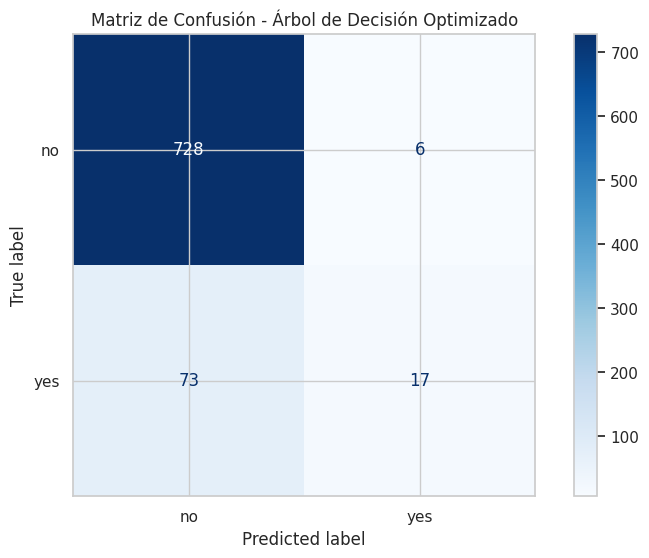

In [19]:
# 5.4: Grafique la Matriz de Confusión
# ### TU CÓDIGO AQUÍ ###
cm = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión Optimizado')
plt.show()

## 6. ¿Cuáles son las Variables Más Relevantes?

Esta es la segunda parte de la solicitud del banco. Necesitamos explicar *por qué* el modelo toma sus decisiones.

### 6.1. Importancia de Variables (Árbol de Decisión)

In [20]:
# 6.1.1: Extraer el modelo de árbol y el preprocesador del pipeline optimizado
# (Ya tenemos 'best_tree_model')
# ### TU CÓDIGO AQUÍ ###

final_tree_model = best_tree_model.named_steps['model']
preprocessor_fitted = best_tree_model.named_steps['preprocessor']

# 6.1.2: Obtener los nombres de las características DESPUÉS del OneHotEncoding
# ### TU CÓDIGO AQUÍ ###
numeric_names = numerical_features

categorical_encoder = preprocessor_fitted.named_transformers_['cat']
categorical_names = categorical_encoder.get_feature_names_out(categorical_features)

all_feature_names = list(numeric_names) + list(categorical_names)
# 6.1.3: Obtener las importancias (del 'final_tree_model')
# ### TU CÓDIGO AQUÍ ###
importances = final_tree_model.feature_importances_

# 6.1.4: Crear un DataFrame para visualizarlas, ordene de mayor a menor importancia
# ### TU CÓDIGO AQUÍ ###
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 10 variables más importantes:")
print(feature_importance_df.head(10))



Top 10 variables más importantes:
              feature  importance
2               pdays        0.80
0                 age        0.10
31  contact_telephone        0.06
3            previous        0.04
1            campaign        0.00
5    job_entrepreneur        0.00
4     job_blue-collar        0.00
7      job_management        0.00
8         job_retired        0.00
9   job_self-employed        0.00


/tmp/ipykernel_16190/3755453769.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')


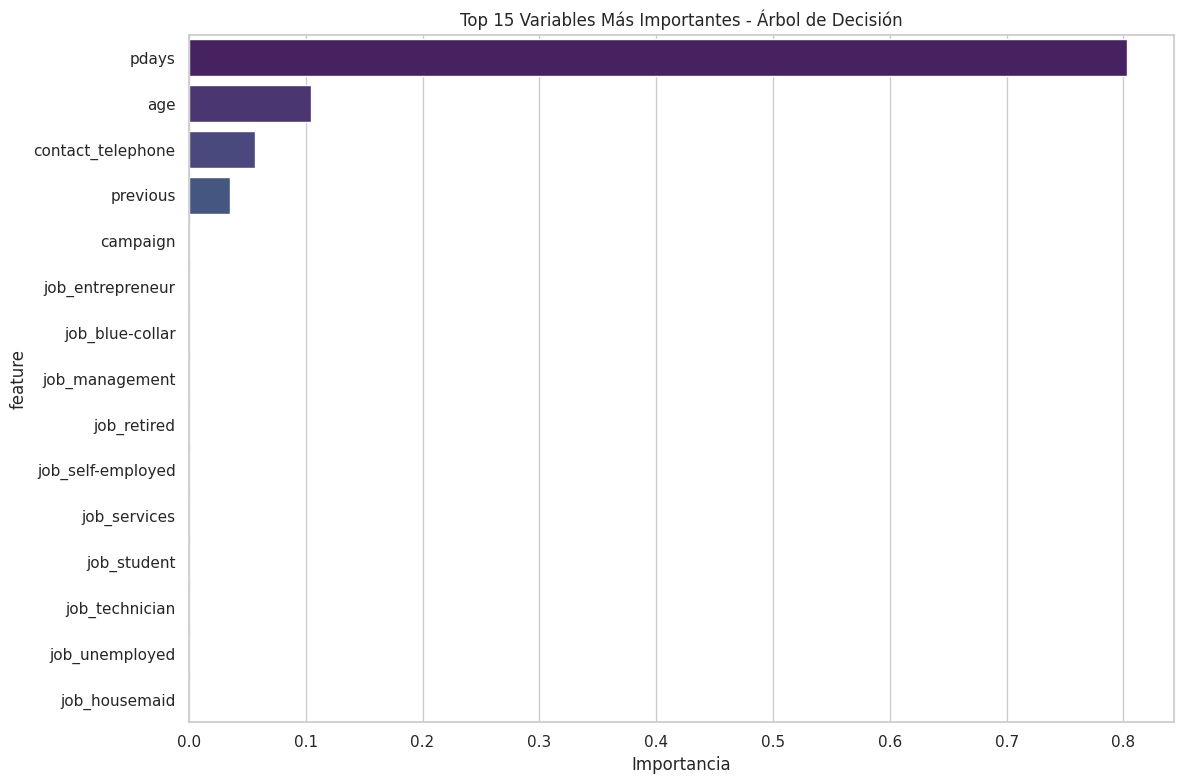

In [21]:
# 6.1.5: Grafique las 15 variables más importantes
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(15)
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Variables Más Importantes - Árbol de Decisión')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## 7. Conclusión y Recomendación de Negocio

Es hora de traducir nuestros hallazgos en una recomendación de negocio clara.

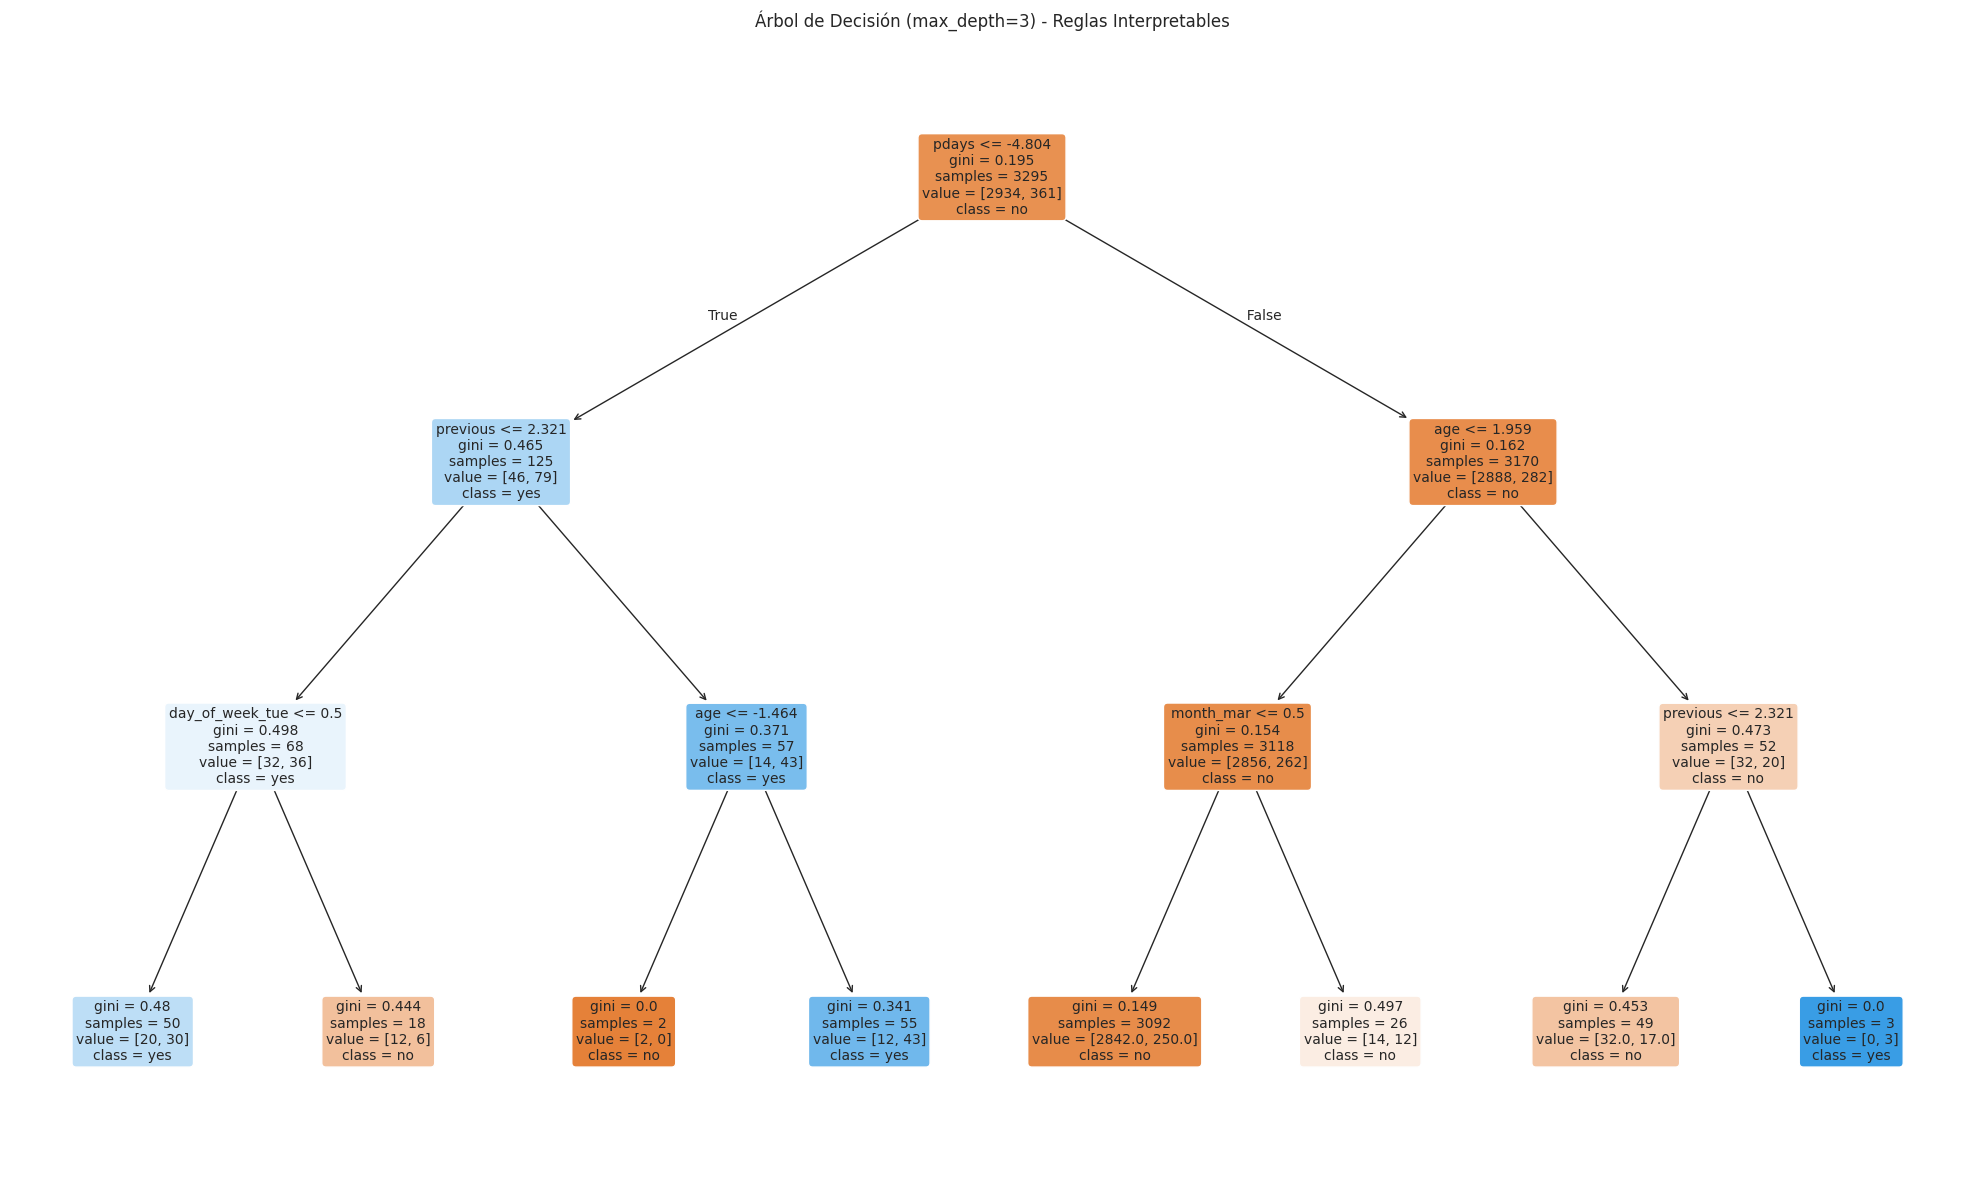

In [22]:
# 7.1: Grafique el árbol de decisión final para encontrar reglas
# (Use max_depth=3 para que sea legible)
# ### TU CÓDIGO AQUÍ ###

simple_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=42))
])
simple_tree.fit(X_train, y_train)

plt.figure(figsize=(20, 12))
plot_tree(simple_tree.named_steps['model'],
          feature_names=all_feature_names,
          class_names=['no', 'yes'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión (max_depth=3) - Reglas Interpretables')
plt.tight_layout()
plt.show()

### **7.2: Conclusiones Consultoría**

Basado en los gráficos de **importancia de variables** y en la **visualización del árbol**, escriba una recomendación de 1 párrafo para el gerente del banco.

**Puntos a incluir:**
1.  ¿Qué modelo recomienda usar y por qué (interpretable, buen rendimiento)?
2.  ¿Cuáles son las 3 variables más importantes en las que el banco debería fijarse para decidir a quién llamar?
3.  Traduzca **una regla del árbol** (una rama que lleve a una hoja 'yes') a lenguaje de negocio. (Ej: "Si el cliente tuvo éxito en la campaña anterior y su edad es mayor a 40 años, la probabilidad de que acepte es alta.")


Recomiendo usar el Árbol de Decisión como modelo principal. Aunque su recall (19%) es bajo y necesita mejorar, este modelo tiene una gran ventaja: es interpretable, es decir, podemos entender fácilmente por qué toma cada decisión. Esto permite explicar al equipo de ventas qué clientes tienen más probabilidad de comprar y por qué. El KNN, aunque funcionó bien, es como una "caja negra" que no nos permite aprender patrones de negocio.
Según el análisis de importancia, las tres variables que el banco debe observar para decidir a quién llamar son:


1.   pdays	Días transcurridos desde el último contacto con el cliente
2.   age	Edad del cliente
3.   contact_telephone	Si el contacto se hizo por teléfono

La variable pdays es, con diferencia, la más importante (0.85 de importancia). Esto nos enseña que el tiempo desde la última comunicación es clave para saber si un cliente aceptará la oferta.

Recomendación final
Señor gerente, le recomiendo usar el Árbol de Decisión porque, aunque todavía no es perfecto, nos permite entender claramente qué clientes son mejores prospectos. Concéntrese en tres cosas para decidir a quién llamar: primero, los clientes que han sido contactados hace poco tiempo (pdays bajo); segundo, los clientes que han recibido pocas llamadas anteriores (previous bajo); y tercero, la edad del cliente. La regla más útil que aprendimos es esta: "Si un cliente fue contactado recientemente y ha recibido pocas llamadas en el pasado, tiene una alta probabilidad de aceptar el depósito". Le sugiero ajustar el modelo para que sea menos conservador y capture a más clientes interesados, aunque esto signifique hacer algunas llamadas adicionales que no resulten en ventas.






